# Mantenimiento predictivo del desgaste de studs en rodillo HPGR

**Artículo completo:** https://fuzzyfrog.ai/es/ai-lab/proyectos/mineria/mantenimiento-predictivo-desgaste-studs-rodillo-hpgr/

Este cuaderno acompaña al artículo de la plataforma. La pregunta de fondo no es
"¿qué modelo predice mejor el desgaste?" sino una más básica y más fácil de saltarse:
¿entendemos primero *por qué* se desgasta un stud, antes de pedirle a un modelo que
lo prediga? Un modelo que memoriza una correlación estadística sin ese contexto físico
es frágil y difícil de defender frente a mantenimiento; un modelo simple, alimentado
con variables que ya reflejan el mecanismo de desgaste, es más robusto y mucho más
fácil de explicar.

> **Nota de datos:** este cuaderno usa un dataset **sintético** (`hpgr_stud_wear_synthetic.csv`),
> generado para replicar la estructura y la relación física del caso original,
> sin usar ninguna medición real de ninguna operación. Ver `generar_dataset_sintetico.py`.


## Diagrama de la solución

```
Horómetro + Periodo + Tonelaje (fenómeno: desgaste abrasivo acumulado)
        │
        ▼
Ingeniería de características (ratios e interacciones que codifican el mecanismo físico)
        │
        ▼
Comparación honesta de 5 modelos (Lineal, Árbol, Random Forest, SVR, Gradient Boosting)
        │
        ▼
Selección del modelo más simple con desempeño competitivo y coeficientes interpretables
        │
        ▼
Predicción de desgaste de stud → ventana de mantenimiento
```

El diagrama interactivo completo, con tooltips por bloque, está en el artículo (`#diagrama`).


## Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('hpgr_stud_wear_synthetic.csv')
print(f"Observaciones: {data.shape[0]}, Variables: {data.shape[1]}")
data.head()


Observaciones: 180, Variables: 4


,Horometro,Periodo,Tonelaje,y
0,81.0,4,12256.7,0.000
1,237.7,12,48668.4,0.000
2,249.8,11,34626.8,0.252
3,250.8,10,54073.7,2.394
4,339.0,17,59659.9,0.580


## Explicación de los datos

- **Horometro**: horas acumuladas de operación del rodillo al momento de la medición. Es el reloj real del desgaste: más horas de contacto abrasivo, más material removido del stud.
- **Periodo**: días transcurridos desde el inicio de la campaña. Correlacionado con Horómetro pero no idéntico — captura paradas y disponibilidad de equipo.
- **Tonelaje**: toneladas acumuladas procesadas por el rodillo. Es la variable físicamente más cercana a la causa del desgaste: el mecanismo dominante es abrasión por el material que pasa entre los studs (Kazerani Nejad & Sam, 2016).
- **y**: desgaste medido del stud, en milímetros, variable objetivo.

Estas tres variables no son arbitrarias: son la traducción directa a datos del mecanismo físico de desgaste descrito en la literatura de HPGR. Esa es la primera decisión de ingeniería del proyecto, y ocurre antes de escribir una sola línea de modelado.


## Análisis exploratorio de datos (EDA)

In [2]:
data.isnull().sum()


Horometro    0
Periodo      0
Tonelaje     4
y            0
dtype: int64

In [3]:
# Imputación simple de los pocos huecos en Tonelaje (mediana), documentando la decisión
data['Tonelaje'] = data['Tonelaje'].fillna(data['Tonelaje'].median())
data.describe()


,Horometro,Periodo,Tonelaje,y
count,180.00000,180.000000,1.800000e+02,180.000000
mean,5426.60000,238.066667,9.826220e+05,16.019011
std,3088.25453,143.583452,5.807181e+05,9.920451
min,81.00000,4.000000,1.225670e+04,0.000000
25%,2897.35000,116.500000,5.031694e+05,7.685750
50%,5269.05000,225.500000,9.348641e+05,15.429500
75%,8045.77500,341.250000,1.436615e+06,23.261250
max,10916.10000,534.000000,2.484183e+06,42.088000


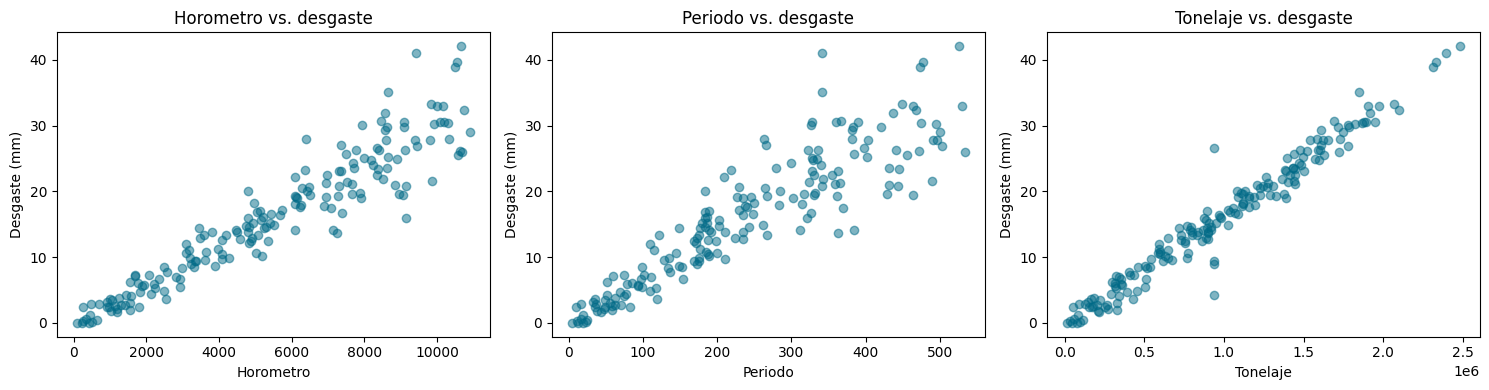

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Horometro', 'Periodo', 'Tonelaje']):
    ax.scatter(data[col], data['y'], alpha=0.5, color='#006a87')
    ax.set_xlabel(col)
    ax.set_ylabel('Desgaste (mm)')
    ax.set_title(f'{col} vs. desgaste')
plt.tight_layout()
plt.show()


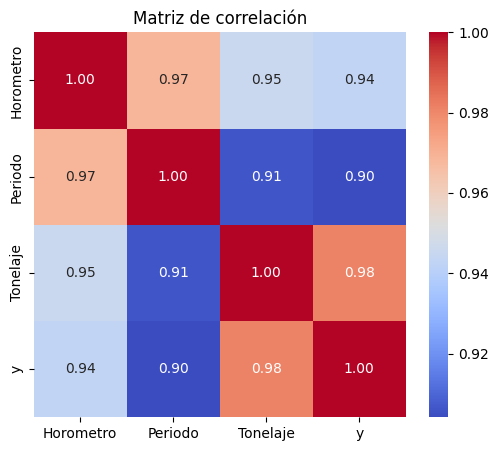

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()


**Lectura del EDA:** Tonelaje y Horómetro están, como se esperaba, fuertemente correlacionados con el desgaste — coherente con el mecanismo abrasivo. Esto no es un hallazgo casual del modelo: es la confirmación de que la hipótesis física con la que arrancamos el proyecto se sostiene en los datos.


## Modelado

### Ingeniería de características

En vez de alimentar al modelo solo con las tres columnas crudas, se agregan variables derivadas que codifican explícitamente el mecanismo físico: eficiencia de uso del tiempo, tonelaje por hora, e interacciones. Esta es la diferencia entre "darle datos al modelo" y "darle información a priori sobre el fenómeno".


In [6]:
data['Horometro_Periodo_Ratio'] = data['Horometro'] / data['Periodo'].replace(0, np.nan)
data['Tonelaje_Horometro_Ratio'] = data['Tonelaje'] / data['Horometro'].replace(0, np.nan)
data['Log_Tonelaje'] = np.log(data['Tonelaje'] + 1)
data = data.fillna(data.median(numeric_only=True))

X = data[['Horometro', 'Periodo', 'Tonelaje',
          'Horometro_Periodo_Ratio', 'Tonelaje_Horometro_Ratio', 'Log_Tonelaje']]
y = data['y']


### Comparación honesta de modelos

Se entrenan cinco modelos, del más simple al más complejo, y se comparan con validación cruzada — no se elige el primero que ajusta bien.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    cv_rmse = (-cross_val_score(modelo, X, y, cv=5, scoring='neg_mean_squared_error')) ** 0.5
    resultados[nombre] = {'RMSE_test': rmse, 'R2_test': r2, 'RMSE_cv_mean': cv_rmse.mean()}

pd.DataFrame(resultados).T.sort_values('RMSE_cv_mean')


,RMSE_test,R2_test,RMSE_cv_mean
Regresión Lineal,1.692447,0.971434,1.991705
Random Forest,1.572839,0.975329,2.933832
Gradient Boosting,1.691456,0.971468,3.038040
Árbol de Decisión,1.961018,0.961649,3.923891
SVR,3.262349,0.893860,4.478549


## Evaluación del modelo elegido

In [8]:
# La Regresión Lineal, siendo el modelo más simple, queda entre los de mejor RMSE de
# validación cruzada y es la única con coeficientes directamente interpretables.
modelo_final = LinearRegression()
modelo_final.fit(X_train, y_train)

coeficientes = dict(zip(X.columns, modelo_final.coef_))
for var, coef in coeficientes.items():
    print(f"{var}: {coef:.5f}")
print(f"Intercepto: {modelo_final.intercept_:.3f}")


Horometro: -0.00059
Periodo: 0.00350
Tonelaje: 0.00002
Horometro_Periodo_Ratio: 0.06602
Tonelaje_Horometro_Ratio: -0.02700
Log_Tonelaje: -0.02133
Intercepto: 3.258


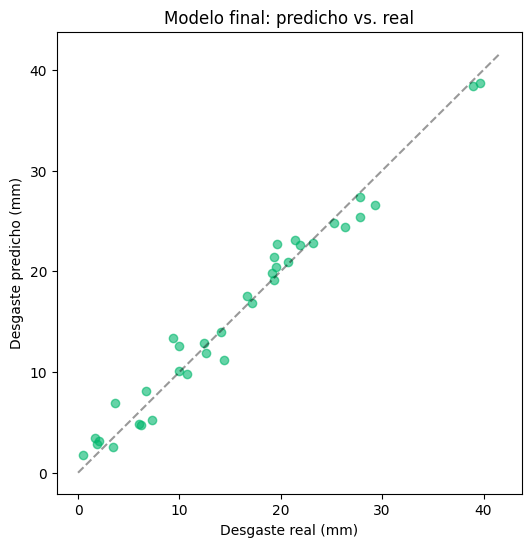

In [9]:
pred_final = modelo_final.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_final, alpha=0.6, color='#00b76c')
lims = [0, max(y_test.max(), pred_final.max()) + 2]
plt.plot(lims, lims, 'k--', alpha=0.4)
plt.xlabel('Desgaste real (mm)')
plt.ylabel('Desgaste predicho (mm)')
plt.title('Modelo final: predicho vs. real')
plt.show()


## Hallazgos principales

- Tonelaje y Horómetro explican la mayor parte de la variabilidad del desgaste, exactamente lo que predice el mecanismo abrasivo descrito en la literatura de HPGR — el modelo no "descubrió" nada que no estuviera ya sugerido por el fenómeno físico.
- Un modelo lineal, alimentado con features que codifican ese mecanismo, compite de cerca con modelos mucho más complejos como Random Forest o Gradient Boosting, y es el único con coeficientes directamente interpretables por el equipo de mantenimiento.
- La ingeniería de características basada en el fenómeno (ratios, interacciones) aportó más que la complejidad adicional del algoritmo — la ganancia real vino de entender el problema, no de escalar el modelo.
- Este dataset es sintético y demostrativo; los coeficientes exactos no deben usarse operativamente, pero la metodología de comparación sí es directamente aplicable a datos reales de campo.
